# V5 Deflated CG 实验

这个 notebook 用来系统比较 `multi-fidelity deflated CG / DPCG` 的几种变体，实验入口主要是 `run_v5_deflated_cg()`。

核心代码分工：
- `gpu/deflation_core.py`：Frank-Vuik deflation 代数、`run_deflated_cg`、`run_deflated_pcg`
- `gpu/deflation_subspace.py`：三种 low-fidelity 子空间构造 `coord_nystrom / freq_trunc / float32`
- `gpu/sanity_check/deflated_cg_validate.py`：最小验证脚本，不是核心实现

本 notebook 的问题设置改为参考 `v1_mat32_eps_topq_eigenspace_compare_tuned_vs_baselines.ipynb`：
- kernel：`make_matern(lengthscale=LENGTHSCALE, nu=NU, dim=DIM, variance=1.0)`，默认 `DIM=3, LENGTHSCALE=0.1, NU=20`，即 Mat32 相关设置
- data：`benchmark.make_dataset(DIM, N_TRAIN, true_func_2d, noise=NOISE, seed=SEED_TRAIN)`，不是 toy 版 `generate_toy_data`
- rank：用 `TOP_Q_LIST` 作为 deflation rank `m` 的扫描值，例如 `[36, 72]`

默认只在 notebook 中展示结果，不额外写 markdown 文件。

In [1]:
import os
import sys
import time
import traceback
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_here = Path.cwd().resolve()
_candidates = [
    _here,
    _here.parent,
    _here.parent.parent,
    _here.parent.parent.parent,
    Path("D:/NU/ML"),
]
for p in _candidates:
    if (p / "efgp_eigenpro_py").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

# 避免 gpu/__init__.py 的额外副作用影响实验导入。
import types
_pkg_root = None
for p in _candidates:
    if (p / "efgp_eigenpro_py" / "gpu").exists():
        _pkg_root = p / "efgp_eigenpro_py"
        break
if _pkg_root is not None and "efgp_eigenpro_py.gpu" not in sys.modules:
    gpu_mod = types.ModuleType("efgp_eigenpro_py.gpu")
    gpu_mod.__path__ = [str(_pkg_root / "gpu")]
    sys.modules["efgp_eigenpro_py.gpu"] = gpu_mod

from efgp_eigenpro_py.benchmark import make_dataset, make_test_set, true_func_2d, true_func_3d, compute_rmse
from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.kernels import make_matern
from efgp_eigenpro_py.gpu.v3_eigenspace import EigenspaceConfig
from efgp_eigenpro_py.gpu.versions import (
    GPURunConfig,
    run_v1_pure_efgp,
    run_v3_full_gpu_eigenspace,
    run_v5_deflated_cg,
    run_v5_oracle_deflated_cg,
)

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

cwd: d:\NU\ML\efgp_eigenpro_py\gpu\sanity_check
sys.path[0]: D:\NU\ML


In [2]:
# ----- 参数：对齐 v1_mat32_eps_topq_eigenspace_compare_tuned_vs_baselines.ipynb -----
# 数据来源：benchmark.make_dataset(DIM, N_TRAIN, true_func_2d, ...)
# Kernel：Matérn，make_matern(lengthscale=LENGTHSCALE, nu=NU, dim=DIM, variance=1.0)

REG_LAMBDA = 0.1
DIM = 3
LENGTHSCALE = 0.1
NU = 20  # Mat32 相关设置，和参考 notebook 一致
EPS_LIST = [1e-7]
TOP_Q_LIST = [36, 72]  # 这里直接作为 V5 deflation rank m 的扫描值

# 数据函数显式指定；true_func_3d 会使用 x[:,0], x[:,1], x[:,2]，是真正 3D synthetic target。
# 如果想完全复现参考 notebook 的旧设置，可改回 DATA_FUNC = true_func_2d。
DATA_FUNC = true_func_3d

# 参考 notebook 主实验是 1_000_000；这里可按显存/时间改大或改小。
N_TRAIN = 10_000_000
N_TEST = 2_000
NOISE = 0.02
SEED_TRAIN = 20230
SEED_TEST = 2027

SOLVE_TOL = 1e-6
GPU_TOL = SOLVE_TOL
GPU_MAXITER = 3000
GPU_CHUNK_SIZE = None
GPU_DEBUG_FINITE_CHECKS = False
GPU_PROFILE_COMPONENTS = True

# plain CG 与 top_q 无关：每个 eps 只 warmup / 正式计时一次，后续所有 top_q 复用同一个 baseline。
PLAIN_CG_WARMUP_RUNS = 1

NUFFT_TOL = 1e-10
L2_SCALED = True

LOWFI_TOL = 1e-3
LOWFI_N_ITER = 10
OVERSAMPLE = 16
COARSE_RATIO = 0.5
BLOCK_COLS = 8
Z_STORAGE_DTYPE = "same_as_A"

METHOD_SPECS = [
    # Oracle tests: use high-fidelity V3 Ritz vectors as Z, but do Frank-Vuik deflation only.
    {
        "variant": "v5_oracle_top_deflation",
        "kind": "oracle",
        "side": "top",
        "extra": {},
    },
    {
        "variant": "v5_oracle_bottom_deflation",
        "kind": "oracle",
        "side": "bottom",
        "extra": {},
    },
    {
        "variant": "v5_oracle_two_sided_deflation",
        "kind": "oracle",
        "side": "two_sided",
        "extra": {"m_bottom": None},
    },
    # Low-fi V5 methods.
    {
        "variant": "v5_coord_nystrom",
        "kind": "lowfi",
        "method": "coord_nystrom",
        "extra": {},
    },
    {
        "variant": "v5_freq_trunc",
        "kind": "lowfi",
        "method": "freq_trunc",
        "extra": {"coarse_ratio": COARSE_RATIO},
    },
    {
        "variant": "v5_float32",
        "kind": "lowfi",
        "method": "float32",
        "extra": {},
    },
    # Structural baseline only: if this is bad, center/weight coordinate frequency bases are not enough.
    {
        "variant": "v5_freq_box_center_baseline",
        "kind": "lowfi",
        "method": "freq_box",
        "extra": {"freq_box_mode": "center"},
    },
    {
        "variant": "v5_freq_box_weight_baseline",
        "kind": "lowfi",
        "method": "freq_box",
        "extra": {"freq_box_mode": "weight"},
    },
]

APPENDIX_METHOD_SPECS = [
    {
        "variant": "v5_coord_nystrom_jacobi_appendix",
        "kind": "lowfi",
        "method": "coord_nystrom",
        "extra": {"precond": "jacobi"},
    },
]

DISPLAY_COLUMNS = [
    "case",
    "variant",
    "status",
    "m_used",
    "top_q",
    "eps",
    "dim",
    "nu",
    "lengthscale",
    "n_train",
    "mtot",
    "grid_n",
    "cg_iters",
    "hi_n_matvec",
    "lowfi_n_matvec",
    "hi_n_matvec_oracle_eigen",
    "solve_iter_gain",
    "net_hi_gain",
    "time_gain",
    "oracle_side",
    "basis_kind",
    "w_mode",
    "matvec_form",
    "true_relres",
    "deflated_relres",
    "cg_relres",
    "time_total",
    "time_subspace",
    "time_calibration",
    "time_solve",
    "cond_G",
    "invariance_leakage",
    "orthonormality_error",
    "b_def_ratio",
    "rmse_test",
    "note",
]

print("data_source: benchmark.make_dataset / make_test_set")
print("kernel: Matérn")
print("DIM:", DIM)
print("LENGTHSCALE:", LENGTHSCALE)
print("NU:", NU)
print("REG_LAMBDA:", REG_LAMBDA)
print("DATA_FUNC:", DATA_FUNC.__name__)
print("N_TRAIN:", N_TRAIN)
print("EPS_LIST:", EPS_LIST)
print("TOP_Q_LIST:", TOP_Q_LIST)
print("METHODS:", [spec["variant"] for spec in METHOD_SPECS])

data_source: benchmark.make_dataset / make_test_set
kernel: Matérn
DIM: 3
LENGTHSCALE: 0.1
NU: 20
REG_LAMBDA: 0.1
DATA_FUNC: true_func_3d
N_TRAIN: 10000000
EPS_LIST: [1e-07]
TOP_Q_LIST: [36, 72]
METHODS: ['v5_oracle_top_deflation', 'v5_oracle_bottom_deflation', 'v5_oracle_two_sided_deflation', 'v5_coord_nystrom', 'v5_freq_trunc', 'v5_float32', 'v5_freq_box_center_baseline', 'v5_freq_box_weight_baseline']


In [3]:
print("Building dataset ...")
x_train, y_train = make_dataset(DIM, N_TRAIN, DATA_FUNC, noise=NOISE, seed=SEED_TRAIN)
x_test, y_test = make_test_set(DIM, N_TEST, DATA_FUNC, seed=SEED_TEST)

print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test :", x_test.shape, x_test.dtype)

kernel = make_matern(lengthscale=LENGTHSCALE, nu=NU, dim=DIM, variance=1.0)
print("kernel:", kernel)


def _make_problem(eps):
    solver = EFGPSolver(kernel, reg_lambda=REG_LAMBDA, eps=float(eps), nufft_tol=NUFFT_TOL)
    solver.l2scaled = bool(L2_SCALED)
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=GPU_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=GPU_CHUNK_SIZE,
        debug_finite_checks=GPU_DEBUG_FINITE_CHECKS,
        profile_components=GPU_PROFILE_COMPONENTS,
    )
    return solver, x_train, y_train, cfg


def _safe_m_values(data_ctx, m_requested, coarse_ratio=COARSE_RATIO):
    grid_n = int(data_ctx.weights_gpu_flat.size)
    mtot = int(data_ctx.meta["mtot"])
    dim = int(data_ctx.meta["dim"])
    hm = (mtot - 1) // 2
    hm_t = max(1, int(round(float(coarse_ratio) * hm)))
    mtot_t = 2 * hm_t + 1
    n_tilde = int(mtot_t) ** int(dim)

    m_full = min(int(m_requested), max(2, grid_n - 2))
    m_freq = min(int(m_full), max(2, n_tilde - 2))
    return {
        "grid_n": grid_n,
        "mtot": mtot,
        "dim": dim,
        "hm": hm,
        "hm_t": hm_t,
        "mtot_t": mtot_t,
        "n_tilde": n_tilde,
        "m_full": m_full,
        "m_freq": m_freq,
    }


def _ok_true_relres(d, base_relres):
    v = float(d.get("true_relres", np.nan))
    if not np.isfinite(v):
        return False
    return v <= max(10.0 * GPU_TOL, 10.0 * float(base_relres) + GPU_TOL)


def _predict_rmse(out):
    try:
        from efgp_eigenpro_py.gpu.v1_ops import predict_v1
        yhat_gpu = predict_v1(out.backend, out.data_ctx, x_test, out.beta_gpu)
        if hasattr(out.backend.xp, "asnumpy"):
            yhat = out.backend.xp.asnumpy(yhat_gpu)
        elif hasattr(yhat_gpu, "get"):
            yhat = yhat_gpu.get()
        else:
            yhat = np.asarray(yhat_gpu)
        return compute_rmse(np.asarray(yhat).reshape(-1), y_test)
    except Exception:
        return np.nan


def _base_row(case, eps, top_q, variant, status, m_used, safe, d, note, rmse_test=np.nan):
    return {
        "case": case,
        "variant": variant,
        "status": status,
        "m_used": int(m_used),
        "eps": float(eps),
        "dim": int(DIM),
        "nu": float(NU),
        "lengthscale": float(LENGTHSCALE),
        "n_train": int(N_TRAIN),
        "top_q": int(top_q),
        "mtot": int(safe["mtot"]),
        "grid_n": int(safe["grid_n"]),
        "cg_iters": np.nan,
        "hi_n_matvec": np.nan,
        "lowfi_n_matvec": np.nan,
        "hi_n_matvec_oracle_eigen": d.get("hi_n_matvec_oracle_eigen", np.nan),
        "solve_iter_gain": np.nan,
        "net_hi_gain": np.nan,
        "time_gain": np.nan,
        "oracle_side": d.get("oracle_side", ""),
        "basis_kind": d.get("basis_kind", ""),
        "w_mode": d.get("w_mode", ""),
        "matvec_form": d.get("matvec_form", ""),
        "true_relres": np.nan,
        "deflated_relres": np.nan,
        "cg_relres": np.nan,
        "time_total": np.nan,
        "time_subspace": np.nan,
        "time_calibration": np.nan,
        "time_solve": np.nan,
        "cond_G": np.nan,
        "invariance_leakage": np.nan,
        "orthonormality_error": np.nan,
        "b_def_ratio": np.nan,
        "rmse_test": float(rmse_test),
        "note": note,
        "raw": d,
    }


def _attach_gain_metrics(row, baseline_diag):
    plain_iters = float(baseline_diag.get("cg_iters", np.nan))
    plain_hi = float(baseline_diag.get("n_matvec", np.nan))
    plain_time = float(baseline_diag.get("time_total", np.nan))
    cg_iters = float(row.get("cg_iters", np.nan))
    hi_n = float(row.get("hi_n_matvec", np.nan))
    time_total = float(row.get("time_total", np.nan))
    row["solve_iter_gain"] = plain_iters - cg_iters if np.isfinite(plain_iters) and np.isfinite(cg_iters) else np.nan
    row["net_hi_gain"] = plain_hi - hi_n if np.isfinite(plain_hi) and np.isfinite(hi_n) else np.nan
    row["time_gain"] = plain_time - time_total if np.isfinite(plain_time) and np.isfinite(time_total) else np.nan
    return row


_PLAIN_CG_CACHE = {}


def _get_plain_cg_baseline(eps):
    key = float(eps)
    if key in _PLAIN_CG_CACHE:
        return _PLAIN_CG_CACHE[key]

    for i in range(int(PLAIN_CG_WARMUP_RUNS)):
        print(f"  warmup plain CG: eps={eps}, run={i + 1}/{PLAIN_CG_WARMUP_RUNS}")
        solver_w, x_w, y_w, cfg_w = _make_problem(eps)
        _ = run_v1_pure_efgp(solver_w, x_w, y_w, cfg_w)

    print(f"  timed plain CG baseline: eps={eps}, top_q=0")
    solver_b, x_b, y_b, cfg_b = _make_problem(eps)
    out1 = run_v1_pure_efgp(solver_b, x_b, y_b, cfg_b)
    d1 = dict(out1.diagnostics)
    entry = {
        "out": out1,
        "diag": d1,
        "base_relres": float(d1.get("cg_relres", np.nan)),
        "rmse_test": _predict_rmse(out1),
    }
    _PLAIN_CG_CACHE[key] = entry
    return entry


def _run_one_case(eps, top_q):
    solver, x, y, cfg = _make_problem(eps)
    case = f"eps={eps:g}, top_q={top_q}"
    rows = []

    baseline = _get_plain_cg_baseline(eps)
    out1 = baseline["out"]
    d1 = baseline["diag"]
    base_relres = baseline["base_relres"]
    safe = _safe_m_values(out1.data_ctx, top_q, coarse_ratio=COARSE_RATIO)

    plain_safe = dict(safe)
    plain_case = f"eps={eps:g}, top_q=0"
    row = _base_row(plain_case, eps, 0, "v1_plain_cg", "ok", 0, plain_safe, d1, "baseline: no preconditioner; cached per eps", baseline["rmse_test"])
    row.update({
        "cg_iters": int(d1.get("cg_iters", -1)),
        "hi_n_matvec": int(d1.get("n_matvec", -1)),
        "lowfi_n_matvec": 0,
        "cg_relres": float(d1.get("cg_relres", np.nan)),
        "time_total": float(d1.get("time_total", np.nan)),
        "time_subspace": 0.0,
        "time_calibration": 0.0,
        "time_solve": float(d1.get("time_total", np.nan)),
    })
    row = _attach_gain_metrics(row, d1)
    rows.append(row)

    try:
        eig_cfg = EigenspaceConfig(
            q_max=int(safe["m_full"]),
            block_size=int(safe["m_full"] + OVERSAMPLE),
            n_iter=8,
            method="subspace_iter",
        )
        out3 = run_v3_full_gpu_eigenspace(solver, x, y, cfg, eig_cfg=eig_cfg)
        d3 = dict(out3.diagnostics)
        row = _base_row(case, eps, top_q, "v3_eigenspace_pcg", "ok", safe["m_full"], safe, d3, "baseline preconditioned", _predict_rmse(out3))
        row.update({
            "cg_iters": int(d3.get("cg_iters", -1)),
            "hi_n_matvec": int(d3.get("eigen_n_matvec", 0)) + int(d3.get("cg_n_matvec", 0)),
            "lowfi_n_matvec": 0,
            "cg_relres": float(d3.get("cg_relres", np.nan)),
            "time_total": float(d3.get("time_total", np.nan)),
            "time_subspace": float(d3.get("time_eigenspace", np.nan)),
            "time_calibration": float(d3.get("time_precond_build", np.nan)),
            "time_solve": float(d3.get("time_solve", np.nan)),
        })
        rows.append(_attach_gain_metrics(row, d1))
    except Exception:
        row = _base_row(case, eps, top_q, "v3_eigenspace_pcg", "failed", safe["m_full"], safe, {}, traceback.format_exc())
        rows.append(_attach_gain_metrics(row, d1))

    def _append_v5_row(spec):
        kind = str(spec.get("kind", "lowfi"))
        method = spec.get("method", "")
        m_used = safe["m_freq"] if method == "freq_trunc" else safe["m_full"]
        try:
            if kind == "oracle":
                extra = dict(spec.get("extra", {}) or {})
                if spec.get("side") == "two_sided" and extra.get("m_bottom") is None:
                    extra["m_bottom"] = max(1, int(m_used) // 2)
                out5 = run_v5_oracle_deflated_cg(
                    solver,
                    x,
                    y,
                    cfg,
                    m=int(m_used),
                    side=str(spec.get("side", "top")),
                    eig_solver="subspace_iter",
                    eig_n_iter=8,
                    oversample=OVERSAMPLE,
                    block_cols=BLOCK_COLS,
                    z_storage_dtype=Z_STORAGE_DTYPE,
                    **extra,
                )
            else:
                out5 = run_v5_deflated_cg(
                    solver,
                    x,
                    y,
                    cfg,
                    m=int(m_used),
                    method=method,
                    lowfi_tol=LOWFI_TOL,
                    lowfi_n_iter=LOWFI_N_ITER,
                    oversample=OVERSAMPLE,
                    coarse_ratio=COARSE_RATIO,
                    block_cols=BLOCK_COLS,
                    z_storage_dtype=Z_STORAGE_DTYPE,
                    **spec["extra"],
                )
            d5 = dict(out5.diagnostics)
            note = "pass" if _ok_true_relres(d5, base_relres) else "check true_relres"
            if method == "freq_box":
                note = "structural baseline; " + note
            row = _base_row(
                case,
                eps,
                top_q,
                spec["variant"],
                "ok",
                m_used,
                safe,
                d5,
                note,
                _predict_rmse(out5),
            )
            row.update({
                "cg_iters": int(d5.get("cg_iters", -1)),
                "hi_n_matvec": int(d5.get("hi_n_matvec", -1)),
                "lowfi_n_matvec": int(d5.get("lowfi_n_matvec", 0)),
                "hi_n_matvec_oracle_eigen": d5.get("hi_n_matvec_oracle_eigen", np.nan),
                "oracle_side": str(d5.get("oracle_side", "")),
                "basis_kind": str(d5.get("basis_kind", "")),
                "w_mode": str(d5.get("w_mode", "")),
                "matvec_form": str(d5.get("matvec_form", "")),
                "true_relres": float(d5.get("true_relres", np.nan)),
                "deflated_relres": float(d5.get("deflated_relres", np.nan)),
                "time_total": float(d5.get("time_total", np.nan)),
                "time_subspace": float(d5.get("time_subspace", np.nan)),
                "time_calibration": float(d5.get("time_calibration", np.nan)),
                "time_solve": float(d5.get("time_solve", np.nan)),
                "cond_G": float(d5.get("cond_G", np.nan)),
                "invariance_leakage": float(d5.get("invariance_leakage", np.nan)),
                "orthonormality_error": float(d5.get("orthonormality_error", np.nan)),
                "b_def_ratio": float(d5.get("b_def_ratio", np.nan)),
            })
            rows.append(_attach_gain_metrics(row, d1))
        except Exception:
            row = _base_row(case, eps, top_q, spec["variant"], "failed", m_used, safe, {}, traceback.format_exc())
            rows.append(_attach_gain_metrics(row, d1))

    for spec in METHOD_SPECS:
        _append_v5_row(spec)

    return rows

Building dataset ...
x_train: (10000000, 3) float64
y_train: (10000000,) float64
x_test : (2000, 3) float64
kernel: KernelSpec(fam='matern', dim=3, lengthscale=0.1, variance=1.0, nu=20)


In [4]:
# ----- Optional: effective spectrum diagnostics -----
# 这个 cell 默认只定义函数，不自动跑；需要时手动调用 _run_spectrum_probe(eps, top_q, ...)。

SPECTRUM_K = 6
SPECTRUM_MAXITER = 300
SPECTRUM_TOL = 1e-3


def _eigsh_extreme_from_matvec(backend, matvec, n, *, which, k=SPECTRUM_K, tol=SPECTRUM_TOL, maxiter=SPECTRUM_MAXITER):
    xp = backend.xp
    try:
        import cupyx.scipy.sparse.linalg as csl
    except Exception as exc:
        raise RuntimeError("cupyx.scipy.sparse.linalg is required for spectrum probe") from exc

    def _mv(v):
        vv = xp.asarray(v, dtype=xp.complex128).reshape(-1)
        out = xp.empty((int(n),), dtype=xp.complex128)
        matvec(vv, out)
        return out

    op = csl.LinearOperator((int(n), int(n)), matvec=_mv, dtype=xp.complex128)
    vals = csl.eigsh(
        op,
        k=int(min(k, max(1, int(n) - 2))),
        which=str(which),
        return_eigenvectors=False,
        tol=float(tol),
        maxiter=int(maxiter),
    )
    vals = xp.real(xp.asarray(vals, dtype=xp.float64))
    return np.asarray(vals.get() if hasattr(vals, "get") else vals)


def _summarize_spectrum_values(vals_large, vals_small, *, label):
    vals_large = np.asarray(vals_large, dtype=float)
    vals_small = np.asarray(vals_small, dtype=float)
    pos_small = vals_small[vals_small > max(1e-14, 1e-12 * max(float(np.max(np.abs(vals_large))), 1.0))]
    lam_max = float(np.max(vals_large)) if vals_large.size else np.nan
    lam_min_pos = float(np.min(pos_small)) if pos_small.size else np.nan
    return {
        "spectrum_operator": label,
        "lambda_max_est": lam_max,
        "lambda_min_pos_est": lam_min_pos,
        "kappa_eff_est": lam_max / lam_min_pos if np.isfinite(lam_max) and np.isfinite(lam_min_pos) and lam_min_pos > 0 else np.nan,
        "eig_large": vals_large,
        "eig_small": vals_small,
    }


def _build_A_spectrum_operator(eps):
    from efgp_eigenpro_py.gpu.backends import build_gpu_backend_bundle
    from efgp_eigenpro_py.gpu.contexts import GPUOperatorContext, ensure_gpu_data_context
    from efgp_eigenpro_py.gpu.v1_ops import apply_A_v1, gpu_precompute_v1

    solver, x, y, cfg = _make_problem(eps)
    backend = build_gpu_backend_bundle(cfg.backend)
    data_ctx = ensure_gpu_data_context(backend, x, y, state=None)
    data_ctx.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx = GPUOperatorContext()
    data_ctx = gpu_precompute_v1(
        backend, solver.kernel, solver.eps, solver.nufft_tol, data_ctx, op_ctx,
        l2scaled=solver.l2scaled, chunk_size=cfg.chunk_size,
    )
    n = int(data_ctx.rhs_gpu.size)

    def matvec(v, out):
        apply_A_v1(backend, data_ctx, v, float(cfg.reg_lambda), op_ctx, out=out)

    return backend, matvec, n


def _build_v5_deflated_spectrum_operator(eps, top_q, *, method="float32", which="LM", side=None):
    from efgp_eigenpro_py.gpu.backends import build_gpu_backend_bundle
    from efgp_eigenpro_py.gpu.contexts import GPUOperatorContext, ensure_gpu_data_context
    from efgp_eigenpro_py.gpu.deflation_core import build_deflation_data, make_deflated_matvec
    from efgp_eigenpro_py.gpu.deflation_subspace import build_deflation_subspace
    from efgp_eigenpro_py.gpu.v1_ops import apply_A_block_v1, apply_A_v1, gpu_precompute_v1
    from efgp_eigenpro_py.gpu.v3_eigenspace import EigenspaceConfig, estimate_top_eigenspace_v3

    solver, x, y, cfg = _make_problem(eps)
    backend = build_gpu_backend_bundle(cfg.backend)
    xp = backend.xp
    data_ctx = ensure_gpu_data_context(backend, x, y, state=None)
    data_ctx.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx = GPUOperatorContext()
    data_ctx = gpu_precompute_v1(
        backend, solver.kernel, solver.eps, solver.nufft_tol, data_ctx, op_ctx,
        l2scaled=solver.l2scaled, chunk_size=cfg.chunk_size,
    )
    safe = _safe_m_values(data_ctx, top_q, coarse_ratio=COARSE_RATIO)
    m_used = safe["m_freq"] if method == "freq_trunc" else safe["m_full"]

    def apply_A_hi(v, out):
        apply_A_v1(backend, data_ctx, v, float(cfg.reg_lambda), op_ctx, out=out)

    def apply_A_hi_block(V):
        Vv = xp.asarray(V, dtype=xp.complex128)
        if Vv.ndim == 1:
            Vv = Vv.reshape(-1, 1)
        return apply_A_block_v1(backend, data_ctx, Vv, float(cfg.reg_lambda), op_ctx, block_cols=BLOCK_COLS)

    if side is None:
        Z0, _diag = build_deflation_subspace(
            backend, data_ctx, float(cfg.reg_lambda), op_ctx,
            method=method, m=int(m_used), which=which, eig_solver="subspace_iter",
            tol=LOWFI_TOL, n_iter=LOWFI_N_ITER, oversample=OVERSAMPLE,
            coarse_ratio=COARSE_RATIO, return_basis=True,
        )
    else:
        eig_method = "cupy_eigsh" if str(side).lower() in ("bottom", "sm", "smallest") else "subspace_iter"
        eig_cfg = EigenspaceConfig(q_max=int(m_used), block_size=int(m_used + OVERSAMPLE), n_iter=8, method=eig_method, eig_method=eig_method)
        setattr(eig_cfg, "which", "SA" if str(side).lower() in ("bottom", "sm", "smallest") else "LA")
        _vals, Z0, _diag = estimate_top_eigenspace_v3(
            backend=backend,
            apply_A_block_gpu=apply_A_hi_block,
            size=int(data_ctx.rhs_gpu.size),
            cfg=eig_cfg,
        )

    defl_data = build_deflation_data(
        backend, apply_A_hi_block, Z0, rank_tol=1e-12, jitter_ratio=1e-12,
        block_cols=BLOCK_COLS, z_storage_dtype=Z_STORAGE_DTYPE, compute_diagnostics=False,
    )
    matvec = make_deflated_matvec(backend, defl_data, apply_A_hi, op_ctx)
    return backend, matvec, int(data_ctx.rhs_gpu.size)


def _run_spectrum_probe(eps, top_q, operators=("A", "v3_pcg", "v5_oracle_top", "v5_oracle_bottom", "v5_float32")):
    rows = []
    for op_name in operators:
        try:
            if op_name == "A":
                backend, matvec, n = _build_A_spectrum_operator(eps)
            elif op_name == "v3_pcg":
                from efgp_eigenpro_py.gpu.versions import build_v3_pcg_left_precond_matvec
                solver, x, y, cfg = _make_problem(eps)
                eig_cfg = EigenspaceConfig(q_max=int(top_q), block_size=int(top_q + OVERSAMPLE), n_iter=8, method="subspace_iter")
                backend, matvec, n, _meta = build_v3_pcg_left_precond_matvec(solver, x, y, cfg, eig_cfg)
            elif op_name == "v5_oracle_top":
                backend, matvec, n = _build_v5_deflated_spectrum_operator(eps, top_q, side="top")
            elif op_name == "v5_oracle_bottom":
                backend, matvec, n = _build_v5_deflated_spectrum_operator(eps, top_q, side="bottom")
            else:
                method = op_name.replace("v5_", "")
                backend, matvec, n = _build_v5_deflated_spectrum_operator(eps, top_q, method=method)
            vals_large = _eigsh_extreme_from_matvec(backend, matvec, n, which="LA")
            vals_small = _eigsh_extreme_from_matvec(backend, matvec, n, which="SA")
            rows.append(_summarize_spectrum_values(vals_large, vals_small, label=op_name))
        except Exception:
            rows.append({"spectrum_operator": op_name, "error": traceback.format_exc()})
    return pd.DataFrame(rows)


In [5]:
all_rows = []

for eps in EPS_LIST:
    for top_q in TOP_Q_LIST:
        print(f"running case: eps={eps}, top_q={top_q}")
        t0 = time.perf_counter()
        rows = _run_one_case(eps, top_q)
        all_rows.extend(rows)
        print(f"done: eps={eps}, top_q={top_q}, wall={time.perf_counter() - t0:.3f}s")

results_df = pd.DataFrame(all_rows)

plain_df = results_df[results_df["variant"] == "v1_plain_cg"].drop_duplicates(
    subset=["eps", "variant"],
    keep="first",
)
other_df = results_df[results_df["variant"] != "v1_plain_cg"].drop_duplicates(
    subset=["eps", "top_q", "variant"],
    keep="first",
)
results_df = pd.concat([plain_df, other_df], ignore_index=True).sort_values(
    ["eps", "top_q", "variant"],
).reset_index(drop=True)
results_df

running case: eps=1e-07, top_q=36
  warmup plain CG: eps=1e-07, run=1/1
  timed plain CG baseline: eps=1e-07, top_q=0
done: eps=1e-07, top_q=36, wall=137.455s
running case: eps=1e-07, top_q=72
done: eps=1e-07, top_q=72, wall=110.424s


,case,variant,status,m_used,eps,dim,nu,lengthscale,n_train,top_q,mtot,grid_n,cg_iters,hi_n_matvec,lowfi_n_matvec,hi_n_matvec_oracle_eigen,solve_iter_gain,net_hi_gain,time_gain,oracle_side,basis_kind,w_mode,matvec_form,true_relres,deflated_relres,cg_relres,time_total,time_subspace,time_calibration,time_solve,cond_G,invariance_leakage,orthonormality_error,b_def_ratio,rmse_test,note,raw
0,"eps=1e-07, top_q=0",v1_plain_cg,ok,0,1.000000e-07,3,20.0,0.1,10000000,0,23,12167,1134.0,1135.0,0.0,NaN,0.0,0.0,0.000000,,,,,NaN,NaN,9.635389e-07,11.530117,0.000000,0.000000,11.530117,NaN,NaN,NaN,NaN,0.000445,baseline: no preconditioner; cached per eps,"{'version': 'v1', 'status': 'ok', 'nufft_backe..."
1,"eps=1e-07, top_q=36",v3_eigenspace_pcg,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,940.0,1445.0,0.0,NaN,194.0,-310.0,-1.206505,,,,,NaN,NaN,9.553347e-07,12.736622,1.054711,0.007737,2.119865,NaN,NaN,NaN,NaN,0.000446,baseline preconditioned,"{'version': 'v3', 'status': 'ok', 'top_q': 36,..."
2,"eps=1e-07, top_q=36",v5_coord_nystrom,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,1554.0,1592.0,0.0,NaN,-420.0,-457.0,-2.368754,,coord_nystrom,dense,structured_zh,1.563290e-07,9.954348e-07,NaN,13.898871,0.202167,0.037867,4.052227,2.381352,0.043284,1.497369e-15,0.157046,0.000445,pass,"{'version': 'v5_deflated_cg', 'status': 'ok', ..."
3,"eps=1e-07, top_q=36",v5_float32,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,1561.0,1599.0,608.0,NaN,-427.0,-464.0,-2.804955,,float32_dense,dense,structured_zh,1.420976e-07,9.116332e-07,NaN,14.335072,0.784060,0.058823,3.933591,2.365882,0.004719,2.208070e-15,0.155871,0.000445,pass,"{'version': 'v5_deflated_cg', 'status': 'ok', ..."
4,"eps=1e-07, top_q=36",v5_freq_box_center_baseline,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,2200.0,2238.0,0.0,NaN,-1066.0,-1103.0,-3.471402,,freq_box,dense,structured_zh,3.671540e-08,9.350909e-07,NaN,15.001519,0.036023,0.035221,5.254167,43.138229,0.430586,0.000000e+00,0.039264,0.000445,structural baseline; pass,"{'version': 'v5_deflated_cg', 'status': 'ok', ..."
5,"eps=1e-07, top_q=36",v5_freq_box_weight_baseline,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,2198.0,2236.0,0.0,NaN,-1064.0,-1101.0,-3.429317,,freq_box,dense,structured_zh,3.491210e-08,8.891634e-07,NaN,14.959434,0.003352,0.027825,5.266923,43.138229,0.430586,0.000000e+00,0.039264,0.000445,structural baseline; pass,"{'version': 'v5_deflated_cg', 'status': 'ok', ..."
6,"eps=1e-07, top_q=36",v5_freq_trunc,failed,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Traceback (most recent call last):\n File ""C:...",{}
7,"eps=1e-07, top_q=36",v5_oracle_bottom_deflation,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,1560.0,1809.0,0.0,211.0,-426.0,-674.0,-2.241393,bottom,dense,dense,structured_zh,1.470702e-07,9.399454e-07,NaN,13.771510,0.411175,0.056223,3.698543,2.363531,0.000000,2.210414e-15,0.156467,0.000445,pass,"{'version': 'v5_oracle_deflated_cg', 'status':..."
8,"eps=1e-07, top_q=36",v5_oracle_top_deflation,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,1557.0,2099.0,0.0,504.0,-423.0,-964.0,-2.321553,top,dense,dense,structured_zh,1.477209e-07,9.500776e-07,NaN,13.851670,0.486429,0.171371,3.692241,2.368801,0.009258,2.163926e-15,0.155483,0.000445,pass,"{'version': 'v5_oracle_deflated_cg', 'status':..."
9,"eps=1e-07, top_q=36",v5_oracle_two_sided_deflation,ok,36,1.000000e-07,3,20.0,0.1,10000000,36,23,12167,1559.0,2258.0,0.0,643.0,-425.0,-1123.0,-2.779065,two_sided,dense,dense,structured_zh,1.172006e-07,9.976229e-07,NaN,14.309182,0.673409,0.066786,3.965614,3.716386,0.027555,1.736494e-15,0.117480,0.000445,pass,"{'version': 'v5_oracle_deflated_cg', 'status':..."


In [6]:
view_df = results_df.copy()
if "raw" in view_df.columns:
    view_df = view_df.drop(columns=["raw"])

summary_df = view_df[DISPLAY_COLUMNS].sort_values(["case", "variant"])
display(summary_df)

ok_df = view_df[view_df["status"] == "ok"].copy()
if not ok_df.empty:
    pivot_hi = ok_df.pivot(index="case", columns="variant", values="hi_n_matvec")
    pivot_iters = ok_df.pivot(index="case", columns="variant", values="cg_iters")
    pivot_time = ok_df.pivot(index="case", columns="variant", values="time_total")

    print("hi_n_matvec")
    display(pivot_hi)
    print("cg_iters")
    display(pivot_iters)
    print("time_total")
    display(pivot_time)
else:
    print("没有成功结果可展示。")

,case,variant,status,m_used,top_q,eps,dim,nu,lengthscale,n_train,mtot,grid_n,cg_iters,hi_n_matvec,lowfi_n_matvec,hi_n_matvec_oracle_eigen,solve_iter_gain,net_hi_gain,time_gain,oracle_side,basis_kind,w_mode,matvec_form,true_relres,deflated_relres,cg_relres,time_total,time_subspace,time_calibration,time_solve,cond_G,invariance_leakage,orthonormality_error,b_def_ratio,rmse_test,note
0,"eps=1e-07, top_q=0",v1_plain_cg,ok,0,0,1.000000e-07,3,20.0,0.1,10000000,23,12167,1134.0,1135.0,0.0,NaN,0.0,0.0,0.000000,,,,,NaN,NaN,9.635389e-07,11.530117,0.000000,0.000000,11.530117,NaN,NaN,NaN,NaN,0.000445,baseline: no preconditioner; cached per eps
1,"eps=1e-07, top_q=36",v3_eigenspace_pcg,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,940.0,1445.0,0.0,NaN,194.0,-310.0,-1.206505,,,,,NaN,NaN,9.553347e-07,12.736622,1.054711,0.007737,2.119865,NaN,NaN,NaN,NaN,0.000446,baseline preconditioned
2,"eps=1e-07, top_q=36",v5_coord_nystrom,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,1554.0,1592.0,0.0,NaN,-420.0,-457.0,-2.368754,,coord_nystrom,dense,structured_zh,1.563290e-07,9.954348e-07,NaN,13.898871,0.202167,0.037867,4.052227,2.381352,0.043284,1.497369e-15,0.157046,0.000445,pass
3,"eps=1e-07, top_q=36",v5_float32,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,1561.0,1599.0,608.0,NaN,-427.0,-464.0,-2.804955,,float32_dense,dense,structured_zh,1.420976e-07,9.116332e-07,NaN,14.335072,0.784060,0.058823,3.933591,2.365882,0.004719,2.208070e-15,0.155871,0.000445,pass
4,"eps=1e-07, top_q=36",v5_freq_box_center_baseline,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,2200.0,2238.0,0.0,NaN,-1066.0,-1103.0,-3.471402,,freq_box,dense,structured_zh,3.671540e-08,9.350909e-07,NaN,15.001519,0.036023,0.035221,5.254167,43.138229,0.430586,0.000000e+00,0.039264,0.000445,structural baseline; pass
5,"eps=1e-07, top_q=36",v5_freq_box_weight_baseline,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,2198.0,2236.0,0.0,NaN,-1064.0,-1101.0,-3.429317,,freq_box,dense,structured_zh,3.491210e-08,8.891634e-07,NaN,14.959434,0.003352,0.027825,5.266923,43.138229,0.430586,0.000000e+00,0.039264,0.000445,structural baseline; pass
6,"eps=1e-07, top_q=36",v5_freq_trunc,failed,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Traceback (most recent call last):\n File ""C:..."
7,"eps=1e-07, top_q=36",v5_oracle_bottom_deflation,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,1560.0,1809.0,0.0,211.0,-426.0,-674.0,-2.241393,bottom,dense,dense,structured_zh,1.470702e-07,9.399454e-07,NaN,13.771510,0.411175,0.056223,3.698543,2.363531,0.000000,2.210414e-15,0.156467,0.000445,pass
8,"eps=1e-07, top_q=36",v5_oracle_top_deflation,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,1557.0,2099.0,0.0,504.0,-423.0,-964.0,-2.321553,top,dense,dense,structured_zh,1.477209e-07,9.500776e-07,NaN,13.851670,0.486429,0.171371,3.692241,2.368801,0.009258,2.163926e-15,0.155483,0.000445,pass
9,"eps=1e-07, top_q=36",v5_oracle_two_sided_deflation,ok,36,36,1.000000e-07,3,20.0,0.1,10000000,23,12167,1559.0,2258.0,0.0,643.0,-425.0,-1123.0,-2.779065,two_sided,dense,dense,structured_zh,1.172006e-07,9.976229e-07,NaN,14.309182,0.673409,0.066786,3.965614,3.716386,0.027555,1.736494e-15,0.117480,0.000445,pass


hi_n_matvec


variant,v1_plain_cg,v3_eigenspace_pcg,v5_coord_nystrom,v5_float32,v5_freq_box_center_baseline,v5_freq_box_weight_baseline,v5_oracle_bottom_deflation,v5_oracle_top_deflation,v5_oracle_two_sided_deflation
case,,,,,,,,,
"eps=1e-07, top_q=0",1135.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"eps=1e-07, top_q=36",NaN,1445.0,1592.0,1599.0,2238.0,2236.0,1809.0,2099.0,2258.0
"eps=1e-07, top_q=72",NaN,1615.0,1461.0,1468.0,1930.0,1930.0,1865.0,2332.0,2571.0


cg_iters


variant,v1_plain_cg,v3_eigenspace_pcg,v5_coord_nystrom,v5_float32,v5_freq_box_center_baseline,v5_freq_box_weight_baseline,v5_oracle_bottom_deflation,v5_oracle_top_deflation,v5_oracle_two_sided_deflation
case,,,,,,,,,
"eps=1e-07, top_q=0",1134.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"eps=1e-07, top_q=36",NaN,940.0,1554.0,1561.0,2200.0,2198.0,1560.0,1557.0,1559.0
"eps=1e-07, top_q=72",NaN,750.0,1387.0,1394.0,1856.0,1856.0,1436.0,1394.0,1388.0


time_total


variant,v1_plain_cg,v3_eigenspace_pcg,v5_coord_nystrom,v5_float32,v5_freq_box_center_baseline,v5_freq_box_weight_baseline,v5_oracle_bottom_deflation,v5_oracle_top_deflation,v5_oracle_two_sided_deflation
case,,,,,,,,,
"eps=1e-07, top_q=0",11.530117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"eps=1e-07, top_q=36",NaN,12.736622,13.898871,14.335072,15.001519,14.959434,13.77151,13.851670,14.309182
"eps=1e-07, top_q=72",NaN,12.727401,13.414677,14.391144,13.938689,13.945604,13.54827,13.799779,14.422597


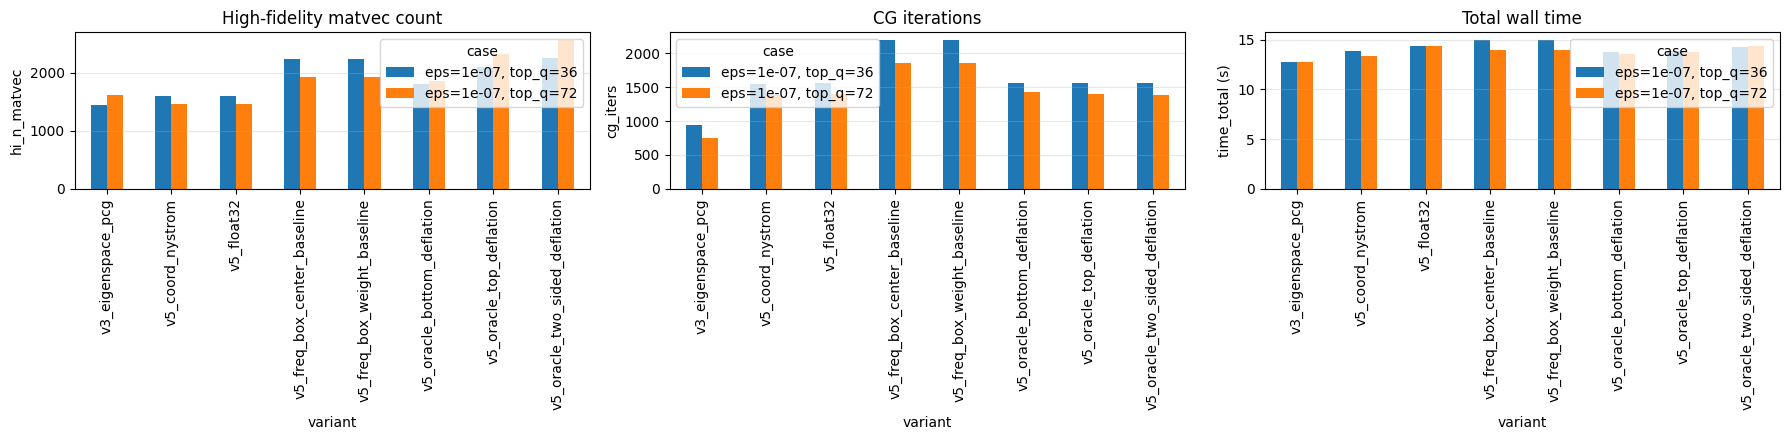

In [7]:
ok_df = results_df[results_df["status"] == "ok"].copy()
plot_df = ok_df[ok_df["variant"] != "v1_plain_cg"].copy()

if plot_df.empty:
    print("没有成功结果可画图。")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    hi_plot = plot_df.pivot(index="variant", columns="case", values="hi_n_matvec")
    it_plot = plot_df.pivot(index="variant", columns="case", values="cg_iters")
    tm_plot = plot_df.pivot(index="variant", columns="case", values="time_total")

    hi_plot.plot(kind="bar", ax=axes[0], title="High-fidelity matvec count")
    axes[0].set_ylabel("hi_n_matvec")
    axes[0].grid(axis="y", alpha=0.3)

    it_plot.plot(kind="bar", ax=axes[1], title="CG iterations")
    axes[1].set_ylabel("cg_iters")
    axes[1].grid(axis="y", alpha=0.3)

    tm_plot.plot(kind="bar", ax=axes[2], title="Total wall time")
    axes[2].set_ylabel("time_total (s)")
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    plot_df[[
        "case",
        "variant",
        "hi_n_matvec",
        "cg_iters",
        "true_relres",
        "time_total",
        "cond_G",
        "invariance_leakage",
        "note",
    ]].sort_values(["case", "hi_n_matvec"])

## 
the idea of deflation is not good. The power of precondition is much worse than eigenpro type.